# Ass3: Data analytics in action

In [19]:
import sklearn as sk
import pandas as pd

from sklearn.preprocessing import StandardScaler

from sklearn.neighbors import KNeighborsClassifier
from sklearn import tree
from sklearn.neural_network import MLPClassifier

from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score

from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import classification_report
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt


# Data reading
DATAFILE = 'trainData.csv'
data = pd.read_csv(DATAFILE)

# Debug
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18000 entries, 0 to 17999
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   id                    18000 non-null  int64  
 1   age                   18000 non-null  int64  
 2   gender                18000 non-null  object 
 3   marital_status        18000 non-null  object 
 4   education_level       18000 non-null  object 
 5   annual_income         18000 non-null  float64
 6   monthly_income        18000 non-null  float64
 7   employment_status     18000 non-null  object 
 8   debt_to_income_ratio  18000 non-null  float64
 9   credit_score          18000 non-null  int64  
 10  loan_amount           18000 non-null  float64
 11  loan_purpose          18000 non-null  object 
 12  interest_rate         18000 non-null  float64
 13  loan_term             18000 non-null  int64  
 14  installment           18000 non-null  float64
 15  num_of_open_account

## Data preprocessing and transformations



In [20]:
# Get unique values in categorical column
categorical_cols = ['gender', 'marital_status', 'education_level', 'employment_status', 'loan_purpose']

for col in categorical_cols:
    print(f"{col}: {data[col].unique()}")

gender: ['Male' 'Female' 'Other']
marital_status: ['Single' 'Married' 'Divorced' 'Widowed']
education_level: ["Bachelor's" 'Other' "Master's" 'High School' 'PhD']
employment_status: ['Self-employed' 'Unemployed' 'Employed' 'Student' 'Retired']
loan_purpose: ['Other' 'Debt consolidation' 'Vacation' 'Medical' 'Car' 'Business'
 'Education' 'Home']


In [21]:
# Check duplicate rows
num_duplicates = data.duplicated().sum()
print('duplicate rows', num_duplicates)

# Drop 'id' because it is not a relevant factor of the results
data_preprocessed = data.drop(columns=['id'])

# Binarize categorical columns
data_preprocessed = pd.get_dummies(data_preprocessed, columns=categorical_cols, dtype=int)

# Identify numerical columns
numerical_cols = ['age', 'annual_income', 'monthly_income', 'debt_to_income_ratio',
                  'credit_score', 'loan_amount', 'interest_rate', 'loan_term',
                  'installment', 'num_of_open_accounts', 'total_credit_limit',
                  'current_balance', 'delinquency_history', 'num_of_delinquencies']
# Z-score normalization
scaler = StandardScaler()
data_preprocessed[numerical_cols] = scaler.fit_transform(data[numerical_cols])

# Debug
data_preprocessed.head()
# data_preprocessed.info()
# data_preprocessed.to_csv('Ass3.csv', index=False)

duplicate rows 0


,age,annual_income,monthly_income,debt_to_income_ratio,credit_score,loan_amount,interest_rate,loan_term,installment,num_of_open_accounts,...,employment_status_Student,employment_status_Unemployed,loan_purpose_Business,loan_purpose_Car,loan_purpose_Debt consolidation,loan_purpose_Education,loan_purpose_Home,loan_purpose_Medical,loan_purpose_Other,loan_purpose_Vacation
0,-1.454578,-0.439364,-0.439363,-0.304229,-0.867093,-0.935413,0.650785,-0.655173,-0.778248,0.891039,...,0,0,0,0,0,0,0,0,1,0
1,1.203014,-0.278723,-0.278724,0.363281,-1.068219,-0.404639,0.319064,-0.655173,-0.226273,-0.890693,...,0,1,0,0,0,0,0,0,1,0
2,1.013186,1.753392,1.753390,0.658892,-2.418636,-0.234499,2.899118,-0.655173,0.103285,0.445606,...,0,0,0,0,0,0,0,0,1,0
3,1.519394,-0.780260,-0.780261,1.755516,0.052340,0.381532,0.794122,1.526314,-0.088380,1.336472,...,0,0,0,0,1,0,0,0,0,0
4,-0.631990,-0.367175,-0.367174,0.105813,-0.522306,0.981294,0.192109,-0.655173,1.228649,0.000173,...,0,1,0,0,1,0,0,0,0,0


## Data splitting

In [22]:
# Split data into attributes (X) and target (y)
X = data_preprocessed.drop(columns=['loan_paid_back'])
y = data_preprocessed['loan_paid_back']

# Split into training (70%) and testing (30%) sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Debug
X_train.info()
y_test.info()

<class 'pandas.core.frame.DataFrame'>
Index: 12600 entries, 5553 to 15795
Data columns (total 39 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   age                              12600 non-null  float64
 1   annual_income                    12600 non-null  float64
 2   monthly_income                   12600 non-null  float64
 3   debt_to_income_ratio             12600 non-null  float64
 4   credit_score                     12600 non-null  float64
 5   loan_amount                      12600 non-null  float64
 6   interest_rate                    12600 non-null  float64
 7   loan_term                        12600 non-null  float64
 8   installment                      12600 non-null  float64
 9   num_of_open_accounts             12600 non-null  float64
 10  total_credit_limit               12600 non-null  float64
 11  current_balance                  12600 non-null  float64
 12  delinquency_history 

## 1. K-NN
### 1.1 Construct K-NN

In [23]:
# Construct classifier
clf_knn = KNeighborsClassifier(n_neighbors = 10)

# Using 5-fold cross validation. Get F1 score by training 5 times
cv_scores_knn = cross_val_score(clf_knn, X_train, y_train, cv=5, scoring='f1')

# Print F1 score of different n_neighbors settings to find a better hyperparameter
print(cv_scores_knn.mean())

# Applying
clf_knn.fit(X_train, y_train)

# Debug
# clf_knn
clf_knn.classes_

0.9016774218891749


array([0, 1])

### 1.2 Evaluate K-NN

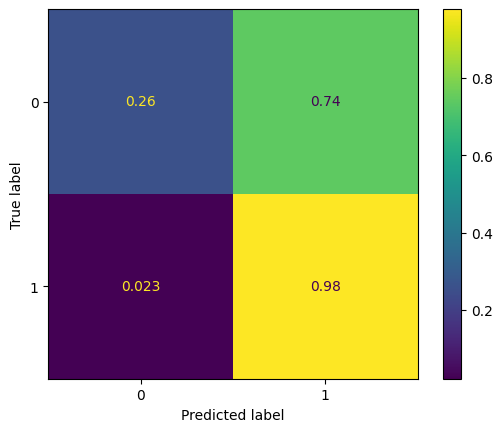

In [30]:
# Confusion matrix
ConfusionMatrixDisplay.from_estimator(clf_knn, X_test, y_test, normalize="true");

In [24]:
# Scores
y_pred_knn = clf_knn.predict(X_test)
print(classification_report(y_test, y_pred_knn))


              precision    recall  f1-score   support

           0       0.74      0.26      0.38      1078
           1       0.84      0.98      0.90      4322

    accuracy                           0.83      5400
   macro avg       0.79      0.62      0.64      5400
weighted avg       0.82      0.83      0.80      5400



The AUC 0.7774878324557706


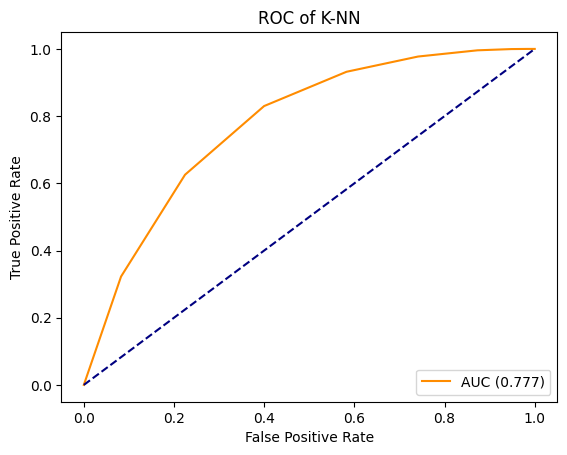

In [25]:
# Plot ROC
y_pred_knn = clf_knn.predict_proba(X_test)
y_pred_knn_class_1 = y_pred_knn[:,1] # probabilities of the class being 1

# Debug
# y_pred_knn_class_1

# Get AUC
auc_knn = roc_auc_score(y_test, y_pred_knn_class_1)
print('The AUC', format(auc_knn))

# Plot
fpr_knn, tpr_knn, _ = roc_curve(y_test, y_pred_knn_class_1, pos_label=1)

plt.figure()
plt.plot(fpr_knn, tpr_knn, color='darkorange',
         label='AUC (%0.3f)' % auc_knn)
plt.plot([0, 1], [0, 1], color='navy', linestyle='--') # random choice

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC of K-NN')
plt.legend(loc="lower right")
plt.show()

## 2. Decision Tree
### 2.1 Construct Decision Tree

In [26]:
# Construct classifier
clf_tree = tree.DecisionTreeClassifier(max_depth=5, random_state=42)

# Using 5-fold cross validation. Get F1 score by training 5 times
cv_scores_tree = cross_val_score(clf_tree, X_train, y_train, cv=5, scoring='f1')

# Print F1 score of different max_depth to find a better hyperparameter
print(cv_scores_tree.mean())

# Applying
clf_tree.fit(X_train, y_train)

# Debug
clf_tree

0.9397717979243698


DecisionTreeClassifier(max_depth=5, random_state=42)

### 2.2 Evaluate Decision Tree

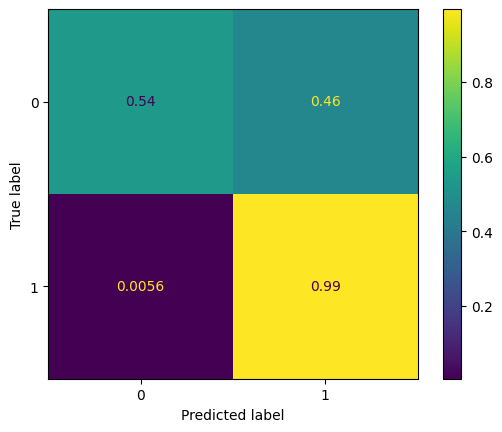

In [27]:
# Confusion matrix
ConfusionMatrixDisplay.from_estimator(clf_tree, X_test, y_test, normalize="true");

In [28]:
# Scores
y_pred_tree = clf_tree.predict(X_test)
print(classification_report(y_test, y_pred_tree))

              precision    recall  f1-score   support

           0       0.96      0.54      0.69      1078
           1       0.90      0.99      0.94      4322

    accuracy                           0.90      5400
   macro avg       0.93      0.76      0.81      5400
weighted avg       0.91      0.90      0.89      5400



The AUC 0.8672755733061809


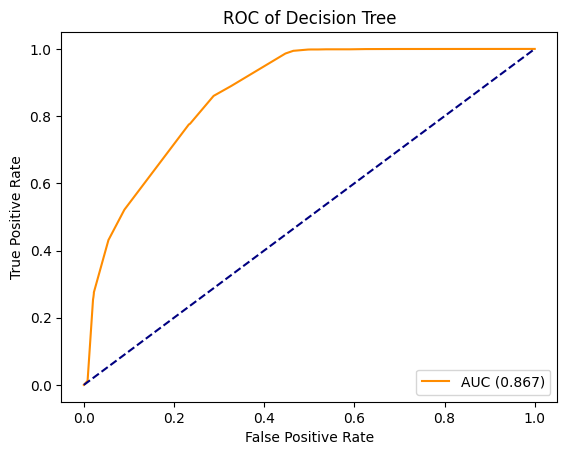

In [29]:
# Plot ROC
y_pred_tree = clf_tree.predict_proba(X_test)
y_pred_tree_class_1 = y_pred_tree[:,1] # probabilities of the class being 1

# Debug
# y_pred_tree_class_1

# Get AUC
auc_tree = roc_auc_score(y_test, y_pred_tree_class_1)
print('The AUC', format(auc_tree))

# Plot
fpr_tree, tpr_tree, _ = roc_curve(y_test, y_pred_tree_class_1, pos_label=1)

plt.figure()
plt.plot(fpr_tree, tpr_tree, color='darkorange',
         label='AUC (%0.3f)' % auc_tree)
plt.plot([0, 1], [0, 1], color='navy', linestyle='--') # random choice

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC of Decision Tree')
plt.legend(loc="lower right")
plt.show()

## 3. MLP
### 3.1 Construct MLP

In [14]:
clf_mlp = MLPClassifier(hidden_layer_sizes=(50, 50), max_iter=1000, random_state=0) # max_iter: Maximum iterations

# Using 5-fold cross validation. Get F1 score by training 5 times
cv_scores_mlp = cross_val_score(clf_mlp, X_train, y_train, cv=5, scoring='f1')

# Print F1 score of different settings to find a better hyperparameter.
print(cv_scores_mlp.mean())

# Applying
clf_mlp.fit(X_train, y_train)

# Debug
clf_mlp

0.9013301387151321


MLPClassifier(hidden_layer_sizes=(50, 50), max_iter=1000, random_state=0)

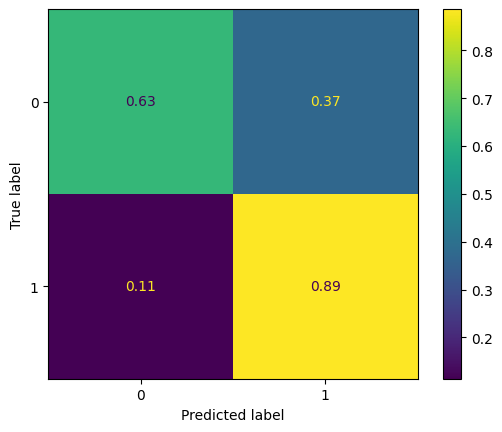

In [15]:
# Confusion matrix
ConfusionMatrixDisplay.from_estimator(clf_mlp, X_test, y_test, normalize="true");

In [16]:
# Scores
y_pred_tree = clf_mlp.predict(X_test)
print(classification_report(y_test, y_pred_tree))

              precision    recall  f1-score   support

           0       0.58      0.63      0.60      1078
           1       0.91      0.89      0.90      4322

    accuracy                           0.83      5400
   macro avg       0.74      0.76      0.75      5400
weighted avg       0.84      0.83      0.84      5400



The AUC 0.8531275031572514


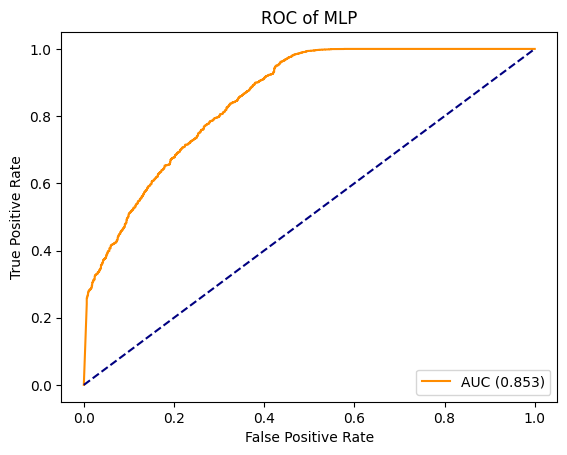

In [17]:
# Plot ROC
y_pred_mlp = clf_mlp.predict_proba(X_test)
y_pred_mlp_class_1 = y_pred_mlp[:,1] # probabilities of the class being 1

# Debug
# y_pred_mlp_class_1

# Get AUC
auc_mlp = roc_auc_score(y_test, y_pred_mlp_class_1)
print('The AUC', format(auc_mlp))

# Plot
fpr_mlp, tpr_mlp, _ = roc_curve(y_test, y_pred_mlp_class_1, pos_label=1)

plt.figure()
plt.plot(fpr_mlp, tpr_mlp, color='darkorange',
         label='AUC (%0.3f)' % auc_mlp)
plt.plot([0, 1], [0, 1], color='navy', linestyle='--') # random choice

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC of MLP')
plt.legend(loc="lower right")
plt.show()